<a href="https://colab.research.google.com/github/hongxu-yn/Southeast-Asia-XCO2-STK-20260901/blob/main/src/step02_stk_reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initialization

In [2]:
from google.colab import drive
import os
import shutil
from pathlib import Path
!pip install -q netCDF4 joblib tqdm xarray pykrige gstools cartopy scipy
drive.mount('/content/drive')
print("✅ Drive mounted successfully and environment initialization complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.5/129.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 131.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 92.5 MB/s eta 0:00:00
Mounted at /content/drive
✅ Drive mounted successfully and environment initialization complete!


In [3]:
import yaml
import geopandas as gpd
from pathlib import Path
import os
import zipfile
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib as mpl        # <--- Add this line
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle, Patch, ConnectionPatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.gridspec as gridspec
from shapely.geometry import box

warnings.filterwarnings("ignore")
mpl.rcParams.update({
    "font.size": 8,            # Global base font size
    "axes.labelsize": 8,       # Axis labels (xlabel, ylabel)
    "xtick.labelsize": 8,      # x-axis tick labels
    "ytick.labelsize": 8,      # y-axis tick labels
    "legend.fontsize": 8,      # Legend font size
    "axes.titlesize": 9,       # Subplot title (slightly larger for distinction)
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

plt.rcParams['axes.unicode_minus'] = False

def add_scalebar(ax, length_km=1000, location=(0.05, 0.05)):
    x0, x1, y0, y1 = ax.get_extent(ccrs.PlateCarree())
    lon_s, lat_s = x0 + (x1-x0)*location[0], y0 + (y1-y0)*location[1]
    lon_e = lon_s + (length_km / (111.32 * np.cos(np.deg2rad(lat_s))))
    kw = dict(transform=ccrs.PlateCarree(), color='k', zorder=20)
    ax.plot([lon_s, lon_e], [lat_s, lat_s], lw=2, **kw)
    tick_h = (y1-y0)*0.025
    for x in [lon_s, lon_e]:
        ax.plot([x, x], [lat_s, lat_s + tick_h], lw=2, **kw)
    ax.text(lon_s, lat_s + tick_h, "0", transform=ccrs.PlateCarree(), ha='center', va='bottom')
    ax.text(lon_e, lat_s + tick_h, f"{length_km} km", transform=ccrs.PlateCarree(), ha='center', va='bottom')

def add_north_arrow(ax, location=(0.90, 0.90), size=0.1):
    x0, x1, y0, y1 = ax.get_extent(ccrs.PlateCarree())
    lon, lat = x0 + (x1-x0)*location[0], y0 + (y1-y0)*location[1]
    h, w = (y1-y0)*size, (y1-y0)*size*0.25
    kw = dict(transform=ccrs.PlateCarree(), color='k', zorder=25)
    ax.add_patch(Polygon([(lon, lat), (lon-w, lat-h), (lon, lat-h*0.7)], fc='k', **kw))
    ax.add_patch(Polygon([(lon, lat), (lon, lat-h*0.7), (lon+w, lat-h)], fc='w', ec='k', lw=0.6, **kw))
    ax.text(lon, lat + (y1-y0)*0.01, 'N', ha='center', va='bottom', transform=ccrs.PlateCarree(), zorder=26)

CONFIG_PATH = Path("/content/drive/MyDrive/Southeast_Asia_XCO2_STK/src/config.yaml")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)


PROJECT_DIR = Path(config['project_root'])

PROC_DIR = PROJECT_DIR / config['paths']['output']['trend']
PROC_DIR.mkdir(parents=True, exist_ok=True)  # Ensure output directory exists
OUTPUT_DIR = PROJECT_DIR / "output"
Validation_DIR= OUTPUT_DIR / "Validation"
gis_dir = PROJECT_DIR / config['paths']['gis']

cams_path = PROJECT_DIR / "data/cams"
stk_nc = PROJECT_DIR / config['paths']['output']['stk_nc']

DOC_DIR = PROJECT_DIR / config['paths']['docs']
DOC_DIR.mkdir(parents=True, exist_ok=True)

sat_root_dir = PROJECT_DIR / config["paths"]["data"]["Satellite"]["root"]
sat_raw_dir = PROJECT_DIR / config["paths"]["data"]["Satellite"]["raw"]
sat_qc_dir = PROJECT_DIR / config["paths"]["data"]["Satellite"]["step01_QA_Control"]
sat_grid_dir = PROJECT_DIR / config["paths"]["data"]["Satellite"]["step02_grid"]
sat_keeling_dir = PROJECT_DIR / config["paths"]["data"]["Satellite"]["step03_Keeling_curve"]

SEA_EXTENT = [87, 148, -16, 33]


# Local Spatiotemporal Kriging - Data Preparation:Calculating residual field

In [4]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import gc
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from joblib import Parallel, delayed
from tqdm import tqdm
import gstools

warnings.filterwarnings("ignore")

# =========================================================
# 1. Path Configuration, Data Loading & Cropping
# =========================================================
print(f"[{time.strftime('%H:%M:%S')}] Step 1: Initializing paths and data...")
stat_tag = "oco2"  # Options: "oco2" or "oco3"


OUT_PATH = sat_keeling_dir / stat_tag
OUT_PATH.mkdir(parents=True, exist_ok=True)

if stat_tag == "oco2":
    xco2_fn = sat_keeling_dir / "oco2_xco2_month_201409_202512.nc"
elif stat_tag == "oco3":
    xco2_fn = sat_keeling_dir / "oco3_xco2_month_201908_202512.nc"
else:
    raise ValueError("stat_tag must be 'oco2' or 'oco3'")

cams_fn = cams_path / "cams_xco2_month_2015_2024_resize.nc"

ds_o = xr.open_dataset(xco2_fn).sortby("time")
ds_c = xr.open_dataset(cams_fn, engine="netcdf4").sortby("time")


if ds_c["xco2"].mean().item() < 1.0:
    ds_c["xco2"] = ds_c["xco2"] * 1e6

common_time = np.intersect1d(ds_o.time.values, ds_c.time.values)
if len(common_time) == 0:
    raise ValueError("⚠️ Satellite data and CAMS have no overlapping time periods!")

ds_o = ds_o.sel(time=common_time)
ds_c = ds_c.sel(time=common_time)


print(f"[{time.strftime('%H:%M:%S')}] Calculating and cleaning residual field (physical threshold ±2.0 ppm)...")
da_res_all_raw = (ds_o["xco2"] - ds_c["xco2"]).astype("float32").load()
res_array_raw = da_res_all_raw.values.copy()

# Only trust observations with a deviation from the background field within ±5 ppm
mask_valid = (res_array_raw >= -5) & (res_array_raw <= 5)
res_array_cleaned = np.full_like(res_array_raw, np.nan)
res_array_cleaned[mask_valid] = res_array_raw[mask_valid]

da_res_all = da_res_all_raw.copy()
da_res_all.values = res_array_cleaned

num_before = np.sum(~np.isnan(res_array_raw))
num_after = np.sum(~np.isnan(res_array_cleaned))
print(f"✅ Residual cleaning complete: {num_before - num_after} extreme noise points removed.")

lat_g = ds_o["lat"].values.astype("float32")
lon_g = ds_o["lon"].values.astype("float32")
unique_times = pd.to_datetime(ds_c.time.values)
months_list = sorted(list(set(unique_times)))
print("Actual variance of residuals:", np.nanvar(res_array_cleaned))

[07:16:59] Step 1: Initializing paths and data...
[07:17:08] Calculating and cleaning residual field (physical threshold ±2.0 ppm)...
✅ Residual cleaning complete: 5677 extreme noise points removed.
Actual variance of residuals: 1.173412


# Local Spatiotemporal Kriging - Key Parameters

Algorithm: Adaptive Local Spatiotemporal Ordinary Kriging (ALSTK)
Objective: Fill gaps in satellite XCO2 observations and reconstruct spatiotemporally continuous residual fields.

1.3D Spatiotemporal Retrieval: Leverages cKDTree across longitude, latitude, and time dimensions to identify the most relevant neighbors for each pixel.

2.Pixel-level Adaptive Modeling: Dynamically adjusts range scales and anisotropy ratios based on local point density; prioritizes Ordinary Kriging (OK) with Inverse Distance Weighting (IDW) as a robust fallback.

3.Post-processing: Integrates multi-stage denoising, patch filtering, and distance-based decay for seamless blending of observations and interpolations.

In [5]:
# -*- coding: utf-8 -*-
import os
import time
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import gstools as gs
from scipy.spatial import cKDTree
from scipy.ndimage import (
    gaussian_filter,
    distance_transform_edt,
    median_filter,
    label
)
from joblib import Parallel, delayed


months_list = pd.to_datetime(da_res_all.time.values).to_pydatetime()
lon_g = da_res_all.lon.values
lat_g = da_res_all.lat.values

res_array = da_res_all.values.astype(np.float32)
ntime, nlat, nlon = res_array.shape

target_lon_mesh, target_lat_mesh = np.meshgrid(lon_g, lat_g)
target_lon_flat = target_lon_mesh.ravel()
target_lat_flat = target_lat_mesh.ravel()
n_targets = target_lon_flat.size


# =========================================================
# 1. Parameter Configuration
# =========================================================
print(f"[{time.strftime('%H:%M:%S')}] Step 1: Configuring the final version of spatiotemporal adaptive local Ordinary Kriging...")

# ---- Time Window ----
TIME_WIN = 2

# ---- Neighbor Search Parameters ----
ADAPTIVE_K = 150
MIN_NEIGHBORS = 10
MAX_NEIGHBORS_USED = 50

# ---- 3D Spatiotemporal Joint Search Scale ----
SEARCH_LON_SCALE = 2.5
SEARCH_LAT_SCALE = 1.5
SEARCH_TIME_SCALE = 1.4
MAX_ST_SEARCH_RADIUS = 4.5

# ---- Local Adaptive Range Scale ----
LEN_X_MIN, LEN_X_MAX = 0.8, 2.5
LEN_T_MIN, LEN_T_MAX = 0.8, 1.8

# ---- Anisotropy Constraint ----
ANIS_RATIO_XY_MIN = 1.0
ANIS_RATIO_XY_MAX = 2.5

# ---- Variogram Parameters ----
GLOBAL_VAR = 1.28
GLOBAL_NUGGET = 0.35
EXACT_MODE = False

# ---- Neighbor Quality Control ----
MIN_UNIQUE_TIMES = 1
MIN_LON_SPREAD = 0.08
MIN_LAT_SPREAD = 0.08

# ---- IDW Fallback ----
IDW_POWER = 2.0
IDW_MAX_USE = 10

# ---- Residual Clipping and Smoothing ----
RES_CLIP_MIN = -1.2
RES_CLIP_MAX = 1.2
SMOOTH_SIGMA = 0.5

# ---- Despeckling / Remove Small Patches ----
DESPECKLE_MEDIAN_SIZE = 5
DESPECKLE_PATCH_DIFF = 0.10
DESPECKLE_PATCH_MIN_SIZE = 6

# ---- Low Observation Month Protection ----
LOW_OBS_THRESHOLD = 300
VERY_LOW_OBS_THRESHOLD = 100

# ---- Distance Decay ----
USE_DISTANCE_DECAY = True
DECAY_SCALE = 1.8

# ---- Observation-Interpolation Smooth Blending ----
BLEND_TRANS_PIXELS = 3.0
BLEND_OBS_WEIGHT_MIN = 0.20

# ---- Parallelization ----
N_JOBS = max(1, (os.cpu_count() or 4) - 2)


# =========================================================
# 2. Utility Functions
# =========================================================
def robust_percentile_span(arr, q=85, fallback=np.nan):
    arr = np.asarray(arr)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return fallback
    return np.percentile(arr, q)


def build_local_model(cond_lon, cond_lat, cond_t):
    """
    Adaptively constructs local spatiotemporal variogram based on local neighbor distribution
    """
    lon_center = np.mean(cond_lon)
    lat_center = np.mean(cond_lat)

    dx = cond_lon - lon_center
    dy = cond_lat - lat_center
    spatial_dist = np.sqrt(dx**2 + dy**2)

    local_span_xy = robust_percentile_span(spatial_dist, q=85, fallback=1.2)
    if not np.isfinite(local_span_xy):
        local_span_xy = 1.2

    len_x = np.clip(local_span_xy * 1.8, LEN_X_MIN, LEN_X_MAX)

    lon_spread = np.nanpercentile(cond_lon, 90) - np.nanpercentile(cond_lon, 10)
    lat_spread = np.nanpercentile(cond_lat, 90) - np.nanpercentile(cond_lat, 10)

    if lat_spread < 1e-6:
        xy_ratio = ANIS_RATIO_XY_MAX
    else:
        xy_ratio = np.clip(lon_spread / lat_spread, ANIS_RATIO_XY_MIN, ANIS_RATIO_XY_MAX)

    ratio_y = 1.0 / xy_ratio

    t_center = np.mean(cond_t)
    dt = np.abs(cond_t - t_center)
    local_span_t = robust_percentile_span(dt, q=80, fallback=1.0)
    if not np.isfinite(local_span_t):
        local_span_t = 1.0

    len_t = np.clip(local_span_t * 1.6 + 0.5, LEN_T_MIN, LEN_T_MAX)
    ratio_t = len_t / len_x

    model = gs.Exponential(
        spatial_dim=2,
        temporal=True,
        len_scale=len_x,
        anis=[ratio_y, ratio_t],
        var=GLOBAL_VAR,
        nugget=GLOBAL_NUGGET
    )
    return model


def screen_neighbors(cond_lon, cond_lat, cond_t, cond_val, st_dists):
    """
    Neighbor screening and quality control
    """
    n_all = len(cond_val)
    if n_all < MIN_NEIGHBORS:
        return None

    order = np.argsort(st_dists)
    cond_lon = cond_lon[order]
    cond_lat = cond_lat[order]
    cond_t = cond_t[order]
    cond_val = cond_val[order]
    st_dists = st_dists[order]

    keep = min(MAX_NEIGHBORS_USED, n_all)
    cond_lon = cond_lon[:keep]
    cond_lat = cond_lat[:keep]
    cond_t = cond_t[:keep]
    cond_val = cond_val[:keep]
    st_dists = st_dists[:keep]

    unique_times = np.unique(cond_t)
    if len(unique_times) < MIN_UNIQUE_TIMES:
        return None

    lon_spread = np.nanpercentile(cond_lon, 90) - np.nanpercentile(cond_lon, 10)
    lat_spread = np.nanpercentile(cond_lat, 90) - np.nanpercentile(cond_lat, 10)

    if (lon_spread < MIN_LON_SPREAD) or (lat_spread < MIN_LAT_SPREAD):
        return None

    return cond_lon, cond_lat, cond_t, cond_val, st_dists


def idw_fallback(cond_val, st_dists, power=2.0, max_use=12):
    """
    IDW residual fallback when STK fails
    """
    cond_val = np.asarray(cond_val, dtype=float)
    st_dists = np.asarray(st_dists, dtype=float)

    good = np.isfinite(cond_val) & np.isfinite(st_dists)
    cond_val = cond_val[good]
    st_dists = st_dists[good]

    if cond_val.size == 0:
        return 0.0

    order = np.argsort(st_dists)
    cond_val = cond_val[order][:max_use]
    st_dists = st_dists[order][:max_use]

    if cond_val.size == 0:
        return 0.0

    if np.min(st_dists) < 1e-6:
        return float(cond_val[np.argmin(st_dists)])

    weights = 1.0 / np.maximum(st_dists, 1e-6) ** power
    wsum = np.sum(weights)

    if wsum <= 0 or not np.isfinite(wsum):
        return 0.0

    pred = np.sum(weights * cond_val) / wsum
    return float(pred)


def remove_small_patch_by_label(arr, diff_threshold=0.18, min_size=5):
    """
    Cleans isolated small patches that are clearly deviated from the local background but have small areas
    """
    arr = np.asarray(arr, dtype=np.float32)
    out = arr.copy()

    bg = gaussian_filter(arr, sigma=1.2)

    # Positive anomaly small patches
    pos_mask = (arr - bg) > diff_threshold
    lab_pos, n_pos = label(pos_mask)

    for k in range(1, n_pos + 1):
        region = (lab_pos == k)
        if region.sum() < min_size:
            out[region] = bg[region]

    # Negative anomaly small patches
    neg_mask = (bg - arr) > diff_threshold
    lab_neg, n_neg = label(neg_mask)

    for k in range(1, n_neg + 1):
        region = (lab_neg == k)
        if region.sum() < min_size:
            out[region] = bg[region]

    return out.astype(np.float32)


def despeckle_residual_field(arr,
                             median_size=3,
                             patch_diff_threshold=0.18,
                             patch_min_size=6):
    """
    Despeckle / Remove Small Patches:
    1) Median filtering to remove salt-and-pepper noise
    2) Small patch area filtering
    """
    arr = np.asarray(arr, dtype=np.float32)

    arr_med = median_filter(arr, size=median_size, mode="nearest")

    arr_clean = remove_small_patch_by_label(
        arr_med,
        diff_threshold=patch_diff_threshold,
        min_size=patch_min_size
    )

    return arr_clean.astype(np.float32)


def blend_observation_and_interp(obs_residual, interp_residual,
                                 obs_mask,
                                 trans_pixels=3.0,
                                 obs_weight_min=0.15):
    """
    Smoothly blends original observed residuals and interpolated residuals to avoid abrupt transitions
    """
    dist_inside = distance_transform_edt(obs_mask)

    obs_weight = 1.0 - np.exp(-(dist_inside / max(trans_pixels, 1e-6)) ** 2)
    obs_weight = obs_weight * (1.0 - obs_weight_min) + obs_weight_min
    obs_weight[~obs_mask] = 0.0

    blended = interp_residual.copy()
    blended[obs_mask] = (
        obs_weight[obs_mask] * obs_residual[obs_mask]
        + (1.0 - obs_weight[obs_mask]) * interp_residual[obs_mask]
    )

    return blended.astype(np.float32)


# =========================================================
# 3. Single Pixel Prediction Function
# =========================================================
def _predict_single_pixel(i, tgt_lon, tgt_lat, tgt_t,
                          neigh_idx, neigh_dist, valid_len,
                          v_lon, v_lat, v_t, v_vals,
                          obs_mask_flat_for_month):
    """
    Single pixel local spatiotemporal Ordinary Kriging
    Prioritize STK, fallback to IDW if failed, finally return 0 residual
    """
    if obs_mask_flat_for_month[i]:
        r, c = divmod(i, nlon)
        return i, res_array[tgt_t, r, c]

    valid_mask = neigh_idx < valid_len
    if valid_mask.sum() == 0:
        return i, 0.0

    idx = neigh_idx[valid_mask]
    st_d = neigh_dist[valid_mask]

    cond_lon = v_lon[idx]
    cond_lat = v_lat[idx]
    cond_t = v_t[idx].astype(float)
    cond_val = v_vals[idx]

    screened = screen_neighbors(cond_lon, cond_lat, cond_t, cond_val, st_d)

    if screened is None:
        pred_idw = idw_fallback(cond_val, st_d, power=IDW_POWER, max_use=IDW_MAX_USE)
        return i, np.float32(pred_idw)

    cond_lon, cond_lat, cond_t, cond_val, st_d = screened

    try:
        model = build_local_model(cond_lon, cond_lat, cond_t)

        krig = gs.krige.Ordinary(
            model,
            cond_pos=[cond_lon, cond_lat, cond_t],
            cond_val=cond_val,
            exact=EXACT_MODE
        )

        pred, _ = krig(([tgt_lon], [tgt_lat], [float(tgt_t)]))
        pred_val = float(pred[0])

        if np.isfinite(pred_val):
            return i, np.float32(pred_val)
        else:
            pred_idw = idw_fallback(cond_val, st_d, power=IDW_POWER, max_use=IDW_MAX_USE)
            return i, np.float32(pred_idw)

    except Exception:
        pred_idw = idw_fallback(cond_val, st_d, power=IDW_POWER, max_use=IDW_MAX_USE)
        return i, np.float32(pred_idw)


# =========================================================
# 4. Single Month Reconstruction
# =========================================================
def krige_for_month(t_idx):
    """
    Executes the final version of local spatiotemporal adaptive Ordinary Kriging for a single month
    """
    print(f"[{time.strftime('%H:%M:%S')}] Month index {t_idx+1}/{ntime} starting...")

    t_start = max(0, t_idx - TIME_WIN)
    t_end = min(ntime - 1, t_idx + TIME_WIN)

    window_data = res_array[t_start:t_end + 1, :, :]
    valid_idx = np.where(~np.isnan(window_data))

    if len(valid_idx[0]) < MIN_NEIGHBORS:
        print("  ⚠️ Too few valid points in the time window, directly returning 0 residual field")
        return t_idx, np.zeros((nlat, nlon), dtype=np.float32)

    valid_t = valid_idx[0] + t_start
    valid_y = valid_idx[1]
    valid_x = valid_idx[2]

    v_lon = lon_g[valid_x].astype(np.float32)
    v_lat = lat_g[valid_y].astype(np.float32)
    v_t = valid_t.astype(np.float32)
    v_vals = window_data[valid_idx].astype(np.float32)

    valid_len = len(v_vals)

    # ---- Build 3D Spatiotemporal KDTree ----
    tree_coords = np.column_stack([
        v_lon / SEARCH_LON_SCALE,
        v_lat / SEARCH_LAT_SCALE,
        v_t / SEARCH_TIME_SCALE
    ]).astype(np.float32)

    tree = cKDTree(tree_coords)

    target_coords = np.column_stack([
        target_lon_flat / SEARCH_LON_SCALE,
        target_lat_flat / SEARCH_LAT_SCALE,
        np.full(n_targets, t_idx / SEARCH_TIME_SCALE, dtype=np.float32)
    ])

    dists, indices = tree.query(
        target_coords,
        k=ADAPTIVE_K,
        distance_upper_bound=MAX_ST_SEARCH_RADIUS
    )

    obs_mask_flat = (~np.isnan(res_array[t_idx])).ravel()
    obs_count_this_month = int(np.isfinite(res_array[t_idx]).sum())
    print(f"  Original observation points for this month: {obs_count_this_month}")

    # ---- Parallel Pixel-by-Pixel Prediction ----
    pixel_results = Parallel(n_jobs=N_JOBS, batch_size='auto', backend='loky')(
        delayed(_predict_single_pixel)(
            i=i,
            tgt_lon=target_lon_flat[i],
            tgt_lat=target_lat_flat[i],
            tgt_t=t_idx,
            neigh_idx=indices[i],
            neigh_dist=dists[i],
            valid_len=valid_len,
            v_lon=v_lon,
            v_lat=v_lat,
            v_t=v_t,
            v_vals=v_vals,
            obs_mask_flat_for_month=obs_mask_flat
        )
        for i in range(n_targets)
    )

    # ---- Fill back to 2D Grid ----
    pred_month = np.full((nlat, nlon), np.nan, dtype=np.float32)
    for i, val in pixel_results:
        r, c = divmod(i, nlon)
        pred_month[r, c] = val

    pred_month = np.where(np.isfinite(pred_month), pred_month, 0.0).astype(np.float32)

    # ---- Residual Clipping ----
    pred_month = np.clip(pred_month, RES_CLIP_MIN, RES_CLIP_MAX).astype(np.float32)

    # ---- Slight Gaussian Smoothing ----
    pred_month_smooth = gaussian_filter(pred_month, sigma=SMOOTH_SIGMA).astype(np.float32)

    # ---- Despeckle / Remove Small Patches ----
    pred_month_smooth = despeckle_residual_field(
        pred_month_smooth,
        median_size=DESPECKLE_MEDIAN_SIZE,
        patch_diff_threshold=DESPECKLE_PATCH_DIFF,
        patch_min_size=DESPECKLE_PATCH_MIN_SIZE
    ).astype(np.float32)

    # ---- Distance Decay: Residuals weaken further from observation tracks ----
    if USE_DISTANCE_DECAY:
        nearest_dist, _ = tree.query(target_coords, k=1)
        decay = np.exp(-(nearest_dist / DECAY_SCALE) ** 2).reshape(nlat, nlon).astype(np.float32)
        pred_month_smooth = pred_month_smooth * decay

    # ---- Low Observation Month Protection ----
    if obs_count_this_month < VERY_LOW_OBS_THRESHOLD:
        print("  ⚠️ Extremely sparse month: Residual field only retains 10%")
        pred_month_smooth = pred_month_smooth * 0.1
    elif obs_count_this_month < LOW_OBS_THRESHOLD:
        shrink = obs_count_this_month / LOW_OBS_THRESHOLD
        print(f"  ⚠️ Sparse month: Residual field scaled down proportionally, shrink={shrink:.2f}")
        pred_month_smooth = pred_month_smooth * shrink

    # ---- Original observed residuals are clipped first, then smoothly blended with interpolated residuals ----
    original_obs = res_array[t_idx].copy()
    original_obs = np.where(
        np.isfinite(original_obs),
        np.clip(original_obs, -1.0, 1.0),
        np.nan
    ).astype(np.float32)

    obs_mask_2d = ~np.isnan(original_obs)

    pred_month_blend = blend_observation_and_interp(
        obs_residual=original_obs,
        interp_residual=pred_month_smooth,
        obs_mask=obs_mask_2d,
        trans_pixels=BLEND_TRANS_PIXELS,
        obs_weight_min=BLEND_OBS_WEIGHT_MIN
    )

    valid_ratio = np.isfinite(pred_month_blend).sum() / pred_month_blend.size * 100
    print(f"[{time.strftime('%H:%M:%S')}] Month index {t_idx+1}/{ntime} Completed, coverage {valid_ratio:.1f}%")

    return t_idx, pred_month_blend.astype(np.float32)

[07:17:32] Step 1: Configuring the final version of spatiotemporal adaptive local Ordinary Kriging...


# Adaptive Local Spatiotemporal Kriging - Implementation

In [6]:
import os
import time
import numpy as np
import xarray as xr
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm

# =========================
# Output path
# =========================
OUT_PATH = PROJECT_DIR / "output"
OUT_DIR = OUT_PATH / "oco2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n{'='*68}")
print("🚀 Starting full time-series monthly STK interpolation and NetCDF export")
print(f"📂 Output directory: {OUT_DIR.resolve()}")
print(f"{'='*68}")

total_months = len(months_list)
processed_count = 0
skipped_count = 0
failed_count = 0

pbar = tqdm(
    enumerate(months_list),
    total=total_months,
    desc="STK Reconstruction",
    unit="month",
    ncols=110
)

for target_t_idx, target_time in pbar:
    target_year = target_time.year
    target_month = target_time.month
    ym_str = f"{target_year}-{target_month:02d}"

    out_filename = f"XCO2_STK_{target_year}{target_month:02d}.nc"
    month_nc = OUT_DIR / out_filename

    if month_nc.exists():
        skipped_count += 1
        pbar.set_postfix_str(f"{ym_str} | skipped")
        tqdm.write(f"⏭️  {ym_str} skipped, file already exists: {out_filename}")
        continue

    start_time = time.time()
    pbar.set_postfix_str(f"{ym_str} | kriging")

    try:
        # -------------------------
        # STK reconstruction
        # -------------------------
        _, pred_month_target = krige_for_month(target_t_idx)

        pbar.set_postfix_str(f"{ym_str} | smoothing")

        cams_bg = ds_c["xco2"].values[target_t_idx].astype(np.float32)
        filled_xco2_raw = cams_bg + pred_month_target

        FINAL_SMOOTH_SIGMA = 0.6
        filled_xco2 = gaussian_filter(
            filled_xco2_raw,
            sigma=FINAL_SMOOTH_SIGMA
        ).astype(np.float32)

        pbar.set_postfix_str(f"{ym_str} | saving")

        # 如果 lat_g / lon_g 是二维网格，这里要先转成一维
        lat_coord = lat_g[:, 0] if np.ndim(lat_g) == 2 else lat_g
        lon_coord = lon_g[0, :] if np.ndim(lon_g) == 2 else lon_g

        ds_out = xr.Dataset(
            {
                "xco2": (
                    ["time", "lat", "lon"],
                    filled_xco2[np.newaxis, :, :],
                    {
                        "units": "ppm",
                        "long_name": "Reconstructed XCO2 (STK + CAMS)"
                    }
                )
            },
            coords={
                "time": [target_time],
                "lat": (
                    ["lat"],
                    lat_coord,
                    {"units": "degrees_north"}
                ),
                "lon": (
                    ["lon"],
                    lon_coord,
                    {"units": "degrees_east"}
                )
            },
            attrs={
                "description": "High-resolution XCO2 reconstructed using STK and CAMS background",
                "creation_date": time.strftime("%Y-%m-%d %H:%M:%S"),
                "smoothing_sigma": FINAL_SMOOTH_SIGMA
            }
        )

        encoding = {
            "xco2": {"zlib": True, "complevel": 4}
        }

        ds_out.to_netcdf(month_nc, encoding=encoding)
        ds_out.close()

        cost_time = time.time() - start_time
        processed_count += 1
        pbar.set_postfix_str(f"{ym_str} | done | {cost_time:.1f}s")

        tqdm.write(
            f"✅ {ym_str} completed | time: {cost_time:.2f} s | saved: {out_filename}"
        )

    except Exception as e:
        failed_count += 1
        cost_time = time.time() - start_time
        pbar.set_postfix_str(f"{ym_str} | failed")
        tqdm.write(
            f"❌ {ym_str} failed after {cost_time:.2f} s | error: {repr(e)}"
        )

print(f"\n{'='*68}")
print("🎉 Monthly interpolation and export finished")
print(f"Total months : {total_months}")
print(f"Processed    : {processed_count}")
print(f"Skipped      : {skipped_count}")
print(f"Failed       : {failed_count}")
print(f"{'='*68}")


🚀 Starting full time-series monthly STK interpolation and NetCDF export
📂 Output directory: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/oco2


STK Reconstruction:   0%|                                                          | 0/130 [00:00<?, ?month/s]

⏭️  2014-10 skipped, file already exists: XCO2_STK_201410.nc
⏭️  2014-11 skipped, file already exists: XCO2_STK_201411.nc
⏭️  2014-12 skipped, file already exists: XCO2_STK_201412.nc
⏭️  2015-01 skipped, file already exists: XCO2_STK_201501.nc
⏭️  2015-02 skipped, file already exists: XCO2_STK_201502.nc
⏭️  2015-03 skipped, file already exists: XCO2_STK_201503.nc
⏭️  2015-04 skipped, file already exists: XCO2_STK_201504.nc
⏭️  2015-05 skipped, file already exists: XCO2_STK_201505.nc
⏭️  2015-06 skipped, file already exists: XCO2_STK_201506.nc
⏭️  2015-07 skipped, file already exists: XCO2_STK_201507.nc
⏭️  2015-08 skipped, file already exists: XCO2_STK_201508.nc
⏭️  2015-09 skipped, file already exists: XCO2_STK_201509.nc
⏭️  2015-10 skipped, file already exists: XCO2_STK_201510.nc
⏭️  2015-11 skipped, file already exists: XCO2_STK_201511.nc
⏭️  2015-12 skipped, file already exists: XCO2_STK_201512.nc
⏭️  2016-01 skipped, file already exists: XCO2_STK_201601.nc
⏭️  2016-02 skipped, fil

In [ ]:
# Merge
import os
import xarray as xr
from pathlib import Path


stat_tag = "oco2"



print(f"\n📦 Performing final file merge...")

files_to_merge = sorted(OUT_DIR.glob(f"XCO2_STK_*.nc"))

if not files_to_merge:
    raise FileNotFoundError(f"No annual files to merge found in: {OUT_PATH}")

start_year = int(str(files_to_merge[0].stem).split('_')[-1][:4])
end_year = int(str(files_to_merge[-1].stem).split('_')[-1][:4])

final_merged_file = sat_keeling_dir / f"{stat_tag}_xco2_month_{start_year}_{end_year}_stk_SEA.nc"

if final_merged_file.exists():
    print(f"✨ Final merged file already exists, skipping merge step: {final_merged_file}")
else:
    print(f"Found {len(files_to_merge)} files ready for merging...")
    ds_final = xr.open_mfdataset(files_to_merge, combine="nested", concat_dim="time", join="override")
    ds_final = ds_final.sortby("time")
    ds_final.to_netcdf(
        final_merged_file,
        encoding=
            {
            "xco2": {"zlib": True, "complevel": 1}
            }
    )

    print(f"✨ Task completed successfully! Final merged file: {final_merged_file}")
    print(f"Data Dimensions: {dict(ds_final.sizes)}")
    ds_final.close()

# Spatiotemporal characteristics of the gap-filled dataset

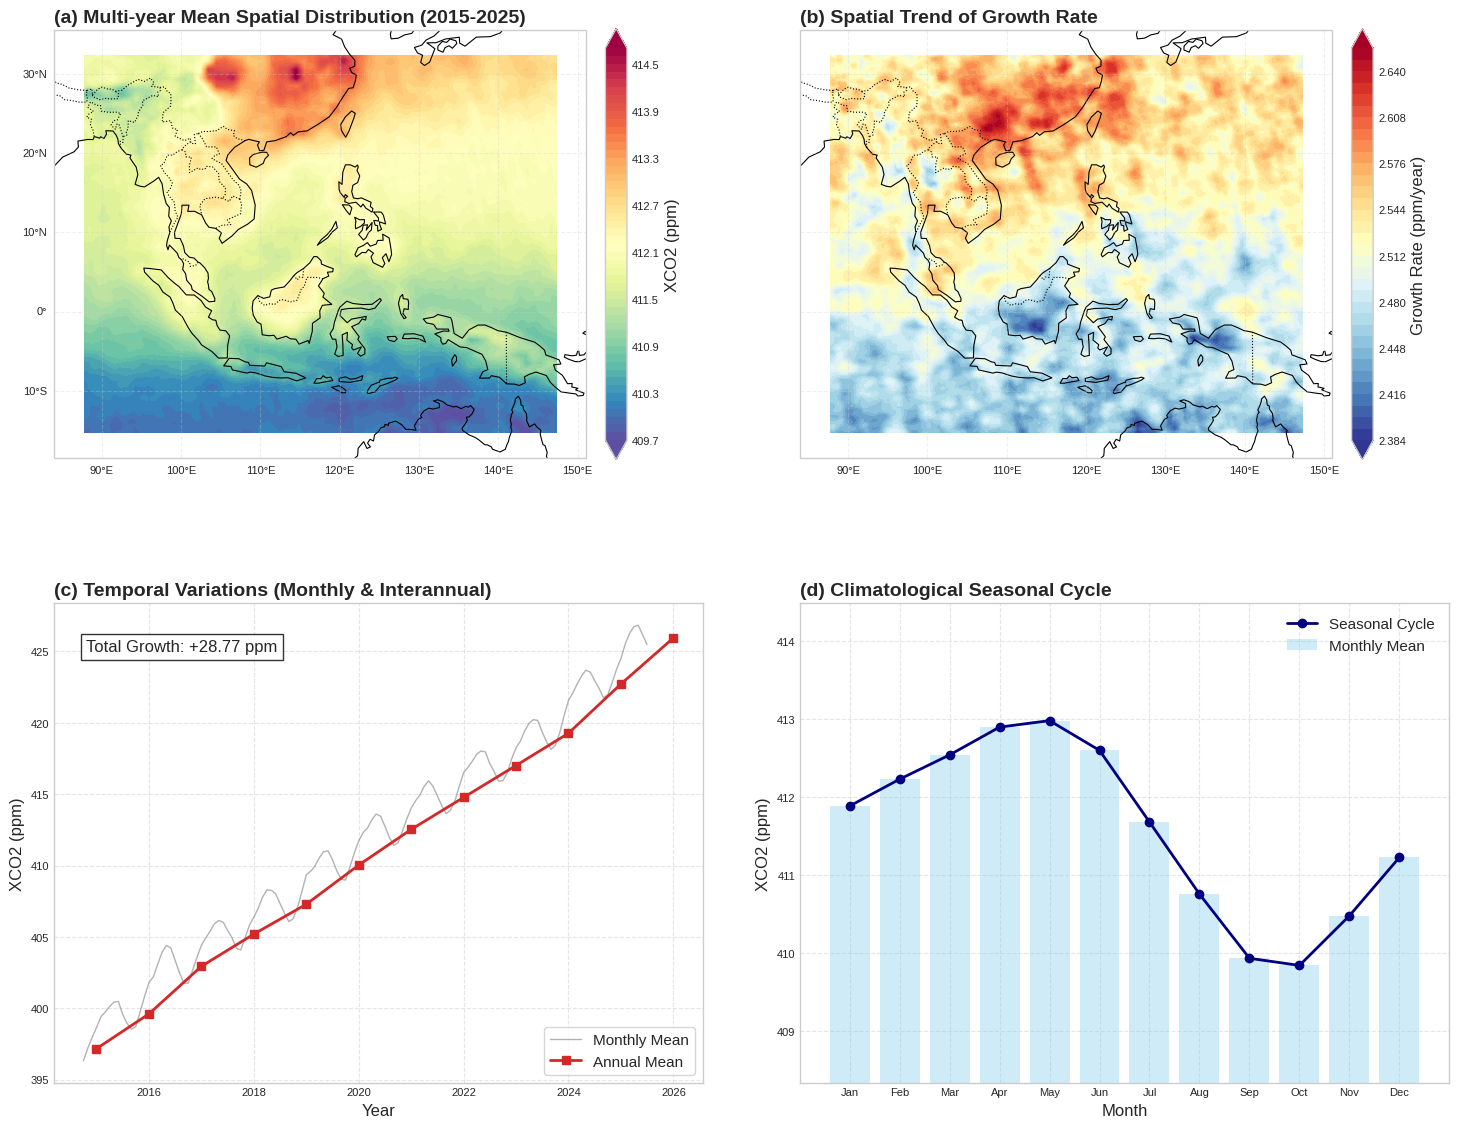

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.ticker as mticker
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
stat_tag='oco2'
start_year=2015
end_year=2024
nc_path= sat_keeling_dir / f"{stat_tag}_xco2_month_{start_year}_{end_year}_stk_SEA.nc"
ds = xr.open_dataset(nc_path)
var_name = list(ds.data_vars)[0]

name_dict = {}
for coord in ds.coords:
    c_low = coord.lower()
    if c_low in ['lat', 'latitude', 'lats']:
        name_dict[coord] = 'lat'
    elif c_low in ['lon', 'longitude', 'lons']:
        name_dict[coord] = 'lon'

if name_dict:
    ds = ds.rename(name_dict)

if 'lat' in ds.data_vars:
    ds = ds.set_coords(['lat', 'lon'])

var_name = list(ds.data_vars)[0]
da = ds[var_name]


da = ds[var_name]
if da.isnull().sum() > 0:
    da = da.interpolate_na(dim='lon', method='linear').interpolate_na(dim='lat', method='linear')

mean_map = da.mean(dim='time')
years_float = [pd.Timestamp(t).year + (pd.Timestamp(t).month-1)/12.0 for t in da.time.values]
da_trend = da.assign_coords(time=years_float)
poly = da_trend.polyfit(dim='time', deg=1)
slope_map = poly['polyfit_coefficients'].sel(degree=1) # Unit: ppm/year


ts_monthly = da.mean(dim=['lat', 'lon'])
ts_yearly = ts_monthly.resample(time='1Y').mean()

# 4. Seasonal Cycle (Line) - Detrended
# First calculate the linear trend
slope_t, intercept_t, _, _, _ = stats.linregress(np.arange(len(ts_monthly)), ts_monthly.values)
trend_line = intercept_t + slope_t * np.arange(len(ts_monthly))
ts_detrended = ts_monthly - trend_line
seasonal_cycle = ts_detrended.groupby('time.month').mean() + ts_monthly.mean() # Add back the mean to maintain the magnitude, or use Anomaly directly

# ================= 2. Plotting (2x2 Panel) =================
fig = plt.figure(figsize=(18, 14))
# Adjust subplot spacing
plt.subplots_adjust(wspace=0.15, hspace=0.25)

# ---------------- Subplot 1: Multi-year Mean Spatial Distribution (Map) ----------------
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
im1 = ax1.contourf(
    mean_map.lon, mean_map.lat, mean_map,
    transform=ccrs.PlateCarree(),
    cmap='Spectral_r', levels=60, extend='both'
)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
# Color bar
cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.9, pad=0.03)
cbar1.set_label('XCO2 (ppm)', fontsize=12)
ax1.set_title('(a) Multi-year Mean Spatial Distribution (2015-2025)', fontsize=14, loc='left', fontweight='bold')
# Lat/Lon labels
gl1 = ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
gl1.top_labels = False
gl1.right_labels = False

# ---------------- Subplot 2: Spatial Trend of Growth Rate (Map) ----------------
ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
im2 = ax2.contourf(
    slope_map.lon, slope_map.lat, slope_map,
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r', levels=40, extend='both' # Red=faster growth
)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.9, pad=0.03)
cbar2.set_label('Growth Rate (ppm/year)', fontsize=12)
ax2.set_title('(b) Spatial Trend of Growth Rate', fontsize=14, loc='left', fontweight='bold')
gl2 = ax2.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
gl2.top_labels = False
gl2.right_labels = False
gl2.left_labels = False # Omit middle latitude labels

# ---------------- Subplot 3: Monthly and Annual Variation Curve (Time Series) ----------------
ax3 = fig.add_subplot(2, 2, 3)
# Plot monthly curve (thin gray line)
ax3.plot(ts_monthly.time, ts_monthly, color='gray', alpha=0.6, linewidth=1, label='Monthly Mean')
# Plot annual mean (red square line) - represents interannual variation
ax3.plot(ts_yearly.time, ts_yearly, 's-', color='#d62728', linewidth=2, label='Annual Mean')

# Calculate overall growth rate for annotation
total_growth = (ts_yearly[-1] - ts_yearly[0]).values
ax3.text(0.05, 0.9, f'Total Growth: +{total_growth:.2f} ppm', transform=ax3.transAxes,
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

ax3.set_ylabel('XCO2 (ppm)', fontsize=12)
ax3.set_xlabel('Year', fontsize=12)
ax3.legend(fontsize=11, frameon=True)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.set_title('(c) Temporal Variations (Monthly & Interannual)', fontsize=14, loc='left', fontweight='bold')

# ---------------- Subplot 4: Multi-year Monthly Mean / Seasonality (Seasonal) ----------------
ax4 = fig.add_subplot(2, 2, 4)
months = np.arange(1, 13)
# Plot histogram background
ax4.bar(months, seasonal_cycle, color='skyblue', alpha=0.4, label='Monthly Mean')
# Plot smooth curve
ax4.plot(months, seasonal_cycle, 'o-', color='navy', linewidth=2, label='Seasonal Cycle')

# Set X-axis as month names
ax4.set_xticks(months)
ax4.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax4.set_ylabel('XCO2 (ppm)', fontsize=12)
ax4.set_xlabel('Month', fontsize=12)

y_min, y_max = seasonal_cycle.min(), seasonal_cycle.max()
ax4.set_ylim(y_min - 1.5, y_max + 1.5)

ax4.legend(fontsize=11)
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.set_title('(d) Climatological Seasonal Cycle', fontsize=14, loc='left', fontweight='bold')

png_fn= DOC_DIR / "Spatial Distribution of reconducted xco2 (2015-2045).png"
plt.savefig(png_fn, dpi=300, bbox_inches='tight')
plt.show()

#Independent Spatial Hold-out Validation

Methodology: Independent Spatial Validation To evaluate the ALSTK model's predictive performance in unsampled regions, a Spatial Hold-out approach was employed for out-of-sample accuracy validation: Data Partitioning: From a representative time-slice (e.g., March 2024), 10% of the original observation points were randomly selected as an independent validation set, while the remaining 90% served as the training set for model fitting. Masking Procedure: Validation pixels were masked (set to NaN) during the interpolation process to ensure a rigorous blind test, preventing any information leakage from the ground truth. Performance Metrics: The model's generalization capability was quantified by comparing masked observations with reconstructed values using the coefficient of determination ( R2 ), Root Mean Square Error (RMSE), and Bias.-- Figure Captions Figure 1.  XCO2  spatial reconstruction and technical validation for March 2024. (a) Original OCO-2 Observations: Initial satellite distribution showing prominent orbital gaps and cloud-induced data voids. (b) CAMS Background Field: Large-scale spatiotemporal prior trends utilized for the reconstruction process. (c) STK Reconstructed Product: Seamless, gap-filled  XCO2  field generated via the ALSTK algorithm. (d) Independent Validation: Scatter plot of the 10% hold-out samples; statistical metrics ( R2 , RMSE, and Bias) demonstrate the model's predictive robustness in unsampled regions.

In [ ]:
import numpy as np
import time
from scipy import stats
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error

extent = [90, 145, -10, 30]
date_list = [(2024, 3), (2024, 6), (2024, 9), (2024, 12)]

results_dict = {}

for target_year, target_month in date_list:
    print(f"\n{'='*60}")
    print(f"🚀 Starting to process target: {target_year}-{target_month:02d}")
    print(f"{'='*60}")

    target_indices = [
        i for i, d in enumerate(months_list)
        if d.year == target_year and d.month == target_month
    ]

    if not target_indices:
        print(f"⚠️ Skipping: No data found for {target_year}-{target_month:02d} in the dataset!")
        continue

    target_t_idx = target_indices[0]
    target_time = months_list[target_t_idx]

    print(f"[{time.strftime('%H:%M:%S')}] 🎯 Found test target: {target_time.strftime('%Y-%m')} (Time Index: {target_t_idx})")

    # ---------------------------------------------------------
    # 90% training / 10% validation split
    # ---------------------------------------------------------
    original_res_this_month = res_array[target_t_idx].copy()
    valid_coords = np.argwhere(~np.isnan(original_res_this_month))
    n_valid = len(valid_coords)

    np.random.seed(42)
    shuffle_idx = np.random.permutation(n_valid)
    n_val = int(n_valid * 0.1)

    val_idx = shuffle_idx[:n_val]
    train_idx = shuffle_idx[n_val:]

    val_coords = valid_coords[val_idx]
    train_coords = valid_coords[train_idx]

    print(f"[{time.strftime('%H:%M:%S')}] 🎲 Dataset split complete: {n_valid} valid observation points this month.")
    print(f"   -> For interpolation (90%): {len(train_idx)} points")
    print(f"   -> For independent validation (10%): {len(val_idx)} points")

    # 挖空 10% 验证点
    for r, c in val_coords:
        res_array[target_t_idx, r, c] = np.nan

    # ---------------------------------------------------------
    # reconstruction
    # ---------------------------------------------------------
    print(f"[{time.strftime('%H:%M:%S')}] Starting full-field STK reconstruction for {target_time.strftime('%Y-%m')}...")
    start_time = time.time()

    _, pred_month_target = krige_for_month(target_t_idx)

    # 恢复原始残差场，避免影响后续月份
    res_array[target_t_idx] = original_res_this_month

    cams_bg = ds_c["xco2"].values[target_t_idx].astype(np.float32)
    filled_xco2_raw = cams_bg + pred_month_target
    filled_xco2 = gaussian_filter(filled_xco2_raw, sigma=0.6).astype(np.float32)

    cost_time = time.time() - start_time
    print(f"[{time.strftime('%H:%M:%S')}] ✅ {target_time.strftime('%Y-%m')} complete! Time taken: {cost_time:.2f} seconds")

    # ---------------------------------------------------------
    # validation data
    # ---------------------------------------------------------
    original_xco2 = ds_o["xco2"].values[target_t_idx].astype(np.float32)

    val_rows, val_cols = val_coords[:, 0], val_coords[:, 1]
    obs_vals = original_xco2[val_rows, val_cols]
    rec_vals = filled_xco2[val_rows, val_cols]

    valid_mask = ~np.isnan(obs_vals) & ~np.isnan(rec_vals)
    obs_vals = obs_vals[valid_mask]
    rec_vals = rec_vals[valid_mask]

    rmse = np.sqrt(mean_squared_error(obs_vals, rec_vals))
    bias = np.mean(rec_vals - obs_vals)
    slope, intercept, r_val, _, _ = stats.linregress(obs_vals, rec_vals)
    r2 = r_val ** 2

    # density scatter
    use_density = True
    try:
        xy = np.vstack([obs_vals, rec_vals])
        z = gaussian_kde(xy)(xy)
        idx = z.argsort()
        x = obs_vals[idx]
        y = rec_vals[idx]
        z = z[idx]
    except Exception:
        use_density = False
        x = obs_vals.copy()
        y = rec_vals.copy()
        z = None

    results_dict[(target_year, target_month)] = {
        "target_time": target_time,
        "target_t_idx": target_t_idx,
        "original_xco2": original_xco2,
        "cams_bg": cams_bg,
        "filled_xco2": filled_xco2,
        "obs_vals": obs_vals,
        "rec_vals": rec_vals,
        "x": x,
        "y": y,
        "z": z,
        "use_density": use_density,
        "rmse": rmse,
        "bias": bias,
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "n": len(obs_vals),
        "val_coords": val_coords
    }

print("\n✅ All requested months have been reconstructed and stored in results_dict.")
print("Available keys:", list(results_dict.keys()))


🚀 Starting to process target: 2024-03
[07:46:11] 🎯 Found test target: 2024-03 (Time Index: 113)
[07:46:11] 🎲 Dataset split complete: 21887 valid observation points this month.
   -> For interpolation (90%): 19699 points
   -> For independent validation (10%): 2188 points
[07:46:11] Starting full-field STK reconstruction for 2024-03...
[07:46:11] Month index 114/130 starting...
  Original observation points for this month: 19699
[07:50:02] Month index 114/130 Completed, coverage 100.0%
[07:50:02] ✅ 2024-03 complete! Time taken: 231.47 seconds

🚀 Starting to process target: 2024-06
[07:50:03] 🎯 Found test target: 2024-06 (Time Index: 116)
[07:50:03] 🎲 Dataset split complete: 17158 valid observation points this month.
   -> For interpolation (90%): 15443 points
   -> For independent validation (10%): 1715 points
[07:50:03] Starting full-field STK reconstruction for 2024-06...
[07:50:03] Month index 117/130 starting...
  Original observation points for this month: 15443


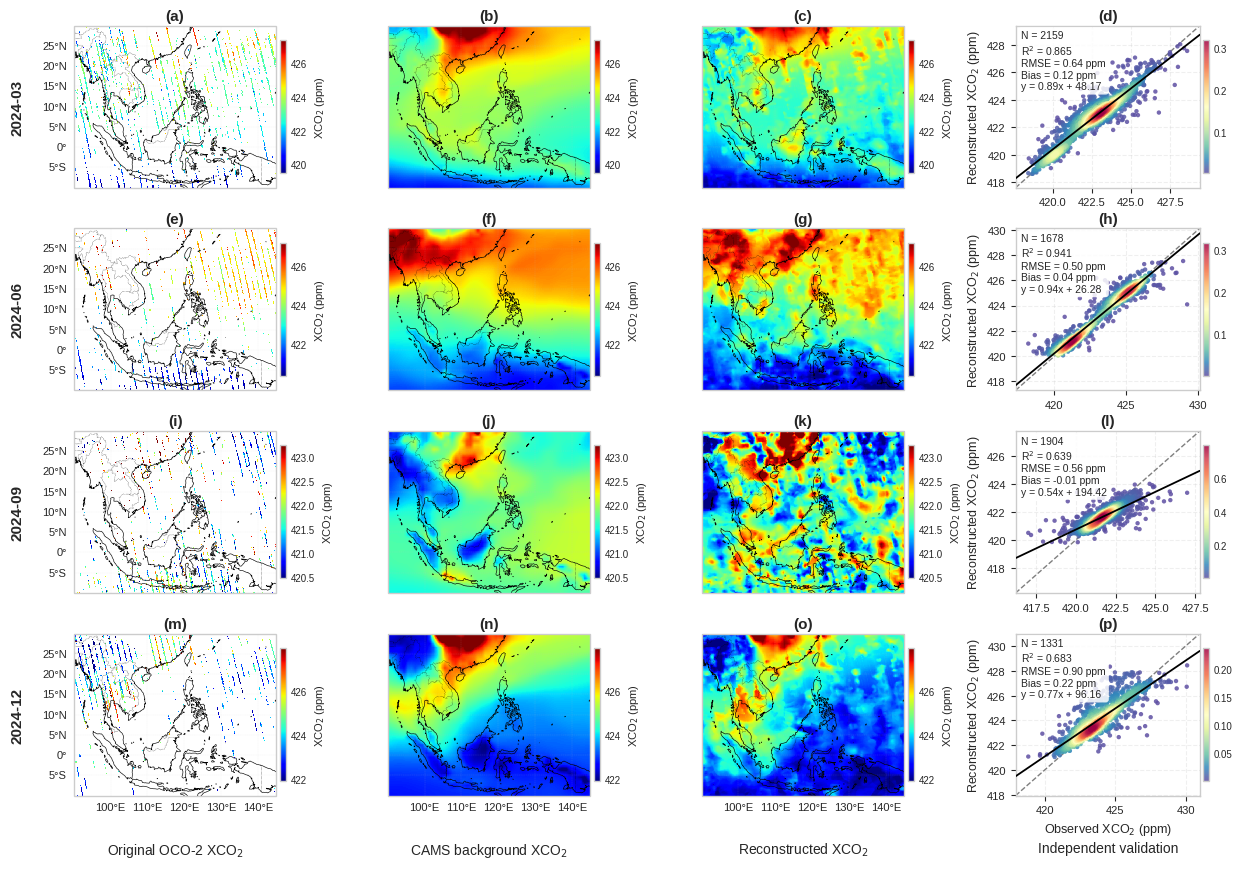

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import string

dataname = [
    "Original OCO-2 XCO$_2$",
    "CAMS background XCO$_2$",
    "Reconstructed XCO$_2$",
    "Independent validation"
]

available_dates = [d for d in date_list if d in results_dict]
n_rows = len(available_dates)
n_cols = 4

fig = plt.figure(figsize=(15, 2.5 * n_rows))
gs = gridspec.GridSpec(
    n_rows, n_cols,
    figure=fig,
    width_ratios=[1.1, 1.1, 1.1, 1],
    wspace=0.3,
    hspace=0.25
)

panel_idx = 0

for row_idx, key in enumerate(available_dates):
    result = results_dict[key]

    target_time = result["target_time"]
    original_xco2 = result["original_xco2"]
    cams_bg = result["cams_bg"]
    filled_xco2 = result["filled_xco2"]

    x = result["x"]
    y = result["y"]
    z = result["z"]
    use_density = result["use_density"]

    rmse = result["rmse"]
    bias = result["bias"]
    slope = result["slope"]
    intercept = result["intercept"]
    r2 = result["r2"]

    # 每一行 4 个子图
    ax1 = fig.add_subplot(gs[row_idx, 0], projection=ccrs.PlateCarree())
    ax2 = fig.add_subplot(gs[row_idx, 1], projection=ccrs.PlateCarree())
    ax3 = fig.add_subplot(gs[row_idx, 2], projection=ccrs.PlateCarree())
    ax4 = fig.add_subplot(gs[row_idx, 3])

    axes_row = [ax1, ax2, ax3, ax4]
    map_axes = [ax1, ax2, ax3]
    map_data = [original_xco2, cams_bg, filled_xco2]

    row_data_all = np.concatenate([
        original_xco2[np.isfinite(original_xco2)],
        cams_bg[np.isfinite(cams_bg)],
        filled_xco2[np.isfinite(filled_xco2)]
    ])

    vmin = np.nanpercentile(row_data_all, 1)
    vmax = np.nanpercentile(row_data_all, 99)

    # -----------------------------
    # map panels
    # -----------------------------
    for col_idx, (ax, data) in enumerate(zip(map_axes, map_data)):
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.45)
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.35)

        im = ax.pcolormesh(
            lon_g, lat_g, data,
            transform=ccrs.PlateCarree(),
            cmap='jet',
            vmin=vmin,
            vmax=vmax,
            shading='auto'
        )

        panel_label = f"({string.ascii_lowercase[panel_idx]})"
        ax.set_title(panel_label, fontsize=11, pad=4, fontweight='bold')
        panel_idx += 1

        ax.set_aspect('auto')

        gl = ax.gridlines(
            draw_labels=True,
            linewidth=0.25,
            linestyle='--',
            alpha=0.3
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 8}
        gl.ylabel_style = {'size': 8}

        if row_idx != n_rows - 1:
            gl.bottom_labels = False

        # 仅第一列保留左侧纬度标签
        if col_idx != 0:
            gl.left_labels = False

        cbar = plt.colorbar(
            im,
            ax=ax,
            orientation='vertical',
            pad=0.015,
            shrink=0.82,
            aspect=22
        )
        cbar.ax.tick_params(labelsize=7)
        cbar.set_label("XCO$_2$ (ppm)", fontsize=8)

    # -----------------------------
    # scatter panel
    # -----------------------------
    d_min = min(x.min(), y.min())
    d_max = max(x.max(), y.max())
    pad = (d_max - d_min) * 0.08
    v_min = d_min - pad
    v_max = d_max + pad

    ax4.set_xlim([v_min, v_max])
    ax4.set_ylim([v_min, v_max])
    ax4.set_aspect('auto')

    if use_density:
        sc = ax4.scatter(
            x, y,
            c=z,
            s=10,
            cmap='Spectral_r',
            edgecolor='none',
            alpha=0.85,
            zorder=2
        )
        cbar4 = plt.colorbar(
            sc,
            ax=ax4,
            orientation='vertical',
            pad=0.015,
            shrink=0.82,
            aspect=22
        )
        cbar4.ax.tick_params(labelsize=7)
    else:
        ax4.scatter(
            x, y,
            s=12,
            facecolor="#9ecae1",
            edgecolor="#3182bd",
            linewidth=0.4,
            alpha=0.85,
            zorder=2
        )

    xx = np.array([v_min, v_max])
    ax4.plot(xx, xx, '--', lw=1.0, color="#7f7f7f", zorder=1)
    ax4.plot(xx, slope * xx + intercept, '-', lw=1.3, color="black", zorder=3)

    panel_label = f"({string.ascii_lowercase[panel_idx]})"
    ax4.set_title(panel_label, fontsize=11, pad=4, fontweight='bold')
    panel_idx += 1

    if row_idx == n_rows - 1:
        ax4.set_xlabel("Observed XCO$_2$ (ppm)", fontsize=9)
    else:
        ax4.set_xlabel("")

    ax4.set_ylabel("Reconstructed XCO$_2$ (ppm)", fontsize=9)

    sign = "+" if intercept >= 0 else "-"
    stats_text = (
        f"N = {len(x)}\n"
        f"R$^2$ = {r2:.3f}\n"
        f"RMSE = {rmse:.2f} ppm\n"
        f"Bias = {bias:.2f} ppm\n"
        f"y = {slope:.2f}x {sign} {abs(intercept):.2f}"
    )

    ax4.text(
        0.03, 0.97,
        stats_text,
        transform=ax4.transAxes,
        fontsize=7.5,
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='none')
    )

    ax4.tick_params(axis='both', labelsize=8, direction='out', length=3.5)
    ax4.grid(True, linestyle='--', alpha=0.3)

    # 左侧时间标注
    date_str = target_time.strftime("%Y-%m")
    ax1.text(
        -0.28, 0.5, date_str,
        transform=ax1.transAxes,
        rotation=90,
        va='center',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

    # 最后一行底部 dataname
    if row_idx == n_rows - 1:
        for col_idx, ax in enumerate(axes_row):
            ax.text(
                0.5, -0.28, dataname[col_idx],
                transform=ax.transAxes,
                ha='center',
                va='top',
                fontsize=10
            )

png_fn = DOC_DIR / "validation_internal_cross_2024.png"
plt.savefig(png_fn, dpi=600, bbox_inches='tight', pad_inches=0.10)
plt.show()

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np


available_dates = [d for d in date_list if d in results_dict]
times = [pd.Timestamp(results_dict[d]["target_time"]) for d in available_dates]

if np.ndim(lon_g) == 2:
    lon_1d = lon_g[0, :]
else:
    lon_1d = lon_g

if np.ndim(lat_g) == 2:
    lat_1d = lat_g[:, 0]
else:
    lat_1d = lat_g

original_stack = np.stack([results_dict[d]["original_xco2"] for d in available_dates], axis=0)
cams_stack = np.stack([results_dict[d]["cams_bg"] for d in available_dates], axis=0)
recon_stack = np.stack([results_dict[d]["filled_xco2"] for d in available_dates], axis=0)

out_ds = xr.Dataset(
    data_vars={
        "original_xco2": (("time", "lat", "lon"), original_stack),
        "cams_background_xco2": (("time", "lat", "lon"), cams_stack),
        "reconstructed_xco2": (("time", "lat", "lon"), recon_stack),
    },
    coords={
        "time": times,
        "lat": lat_1d,
        "lon": lon_1d,
    },
    attrs={
        "title": "Data used for subplot maps",
        "description": "Original OCO-2 XCO2, CAMS background XCO2, and reconstructed XCO2 used for plotting",
    }
)

nc_fn = Validation_DIR / "validation_internal_cross_2024.nc"

encoding = {
    "original_xco2": {"zlib": True, "complevel": 4},
    "cams_background_xco2": {"zlib": True, "complevel": 4},
    "reconstructed_xco2": {"zlib": True, "complevel": 4},
}

out_ds.to_netcdf(nc_fn, encoding=encoding)
print(f"Saved nc: {nc_fn}")


scatter_dfs = []

for d in available_dates:
    result = results_dict[d]
    target_time = pd.Timestamp(result["target_time"])

    if result["use_density"] and result["z"] is not None:
        df_scatter = pd.DataFrame({
            "time": [target_time] * len(result["x"]),
            "observed_xco2": result["x"],
            "reconstructed_xco2": result["y"],
            "point_density": result["z"]
        })
    else:
        df_scatter = pd.DataFrame({
            "time": [target_time] * len(result["obs_vals"]),
            "observed_xco2": result["obs_vals"],
            "reconstructed_xco2": result["rec_vals"]
        })

    scatter_dfs.append(df_scatter)

df_scatter_all = pd.concat(scatter_dfs, ignore_index=True)

csv_fn = Validation_DIR / "validation_internal_cross_2024.csv"
df_scatter_all.to_csv(csv_fn, index=False)
print(f"Saved csv: {csv_fn}")

ValueError: need at least one array to stack

In [8]:
import numpy as np
import pandas as pd
import time
import joblib
import joblib.parallel as jb_parallel

from scipy import stats
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error


# ============================================================
# 0. Settings
# ============================================================
extent = [90, 145, -10, 30]

date_list = [
    (2024, 3),
    (2024, 6),
    (2024, 9),
    (2024, 12)
]

n_repeat = 10
results_dict = {}


# ============================================================
# 1. 强制 joblib 使用 threading
#    解决 Cartopy CRS + loky 多进程序列化错误
# ============================================================
_original_joblib_parallel = joblib.Parallel
_original_module_parallel = jb_parallel.Parallel
_original_global_parallel = krige_for_month.__globals__.get("Parallel", None)


def ThreadParallel(*args, **kwargs):

    # 删除函数内部可能写死的 loky/backend 设置
    kwargs.pop("backend", None)
    kwargs.pop("prefer", None)
    kwargs.pop("require", None)

    return _original_joblib_parallel(
        *args,
        backend="threading",
        **kwargs
    )


joblib.Parallel = ThreadParallel
jb_parallel.Parallel = ThreadParallel

# 如果 krige_for_month 内部使用：
# from joblib import Parallel
# 这里也强制替换
krige_for_month.__globals__["Parallel"] = ThreadParallel

print("✅ joblib 已强制切换为 threading")


# ============================================================
# 2. 先备份四个目标月份的完整残差场
#    注意：运行本代码前 res_array 必须已经重新恢复为完整原始状态
# ============================================================
target_info = {}

for year, month in date_list:

    idx = [
        i for i, d in enumerate(months_list)
        if d.year == year and d.month == month
    ]

    if not idx:
        print(f"⚠️ {year}-{month:02d}: no data")
        continue

    t_idx = idx[0]

    target_info[(year, month)] = {
        "idx": t_idx,
        "res": res_array[t_idx].copy()
    }


# ============================================================
# 3. Repeated holdout validation
# ============================================================
try:

    for target_year, target_month in date_list:

        key = (target_year, target_month)

        if key not in target_info:
            continue

        print("\n" + "=" * 65)
        print(
            f"🚀 {target_year}-{target_month:02d}: "
            f"10% holdout × {n_repeat}"
        )
        print("=" * 65)

        target_t_idx = target_info[key]["idx"]
        target_time = months_list[target_t_idx]

        # 永远使用事先保存的完整残差场
        original_res = target_info[key]["res"].copy()

        original_xco2 = (
            ds_o["xco2"]
            .values[target_t_idx]
            .astype(np.float32)
        )

        cams_bg = (
            ds_c["xco2"]
            .values[target_t_idx]
            .astype(np.float32)
        )

        valid_coords = np.argwhere(
            np.isfinite(original_res)
        )

        n_valid = len(valid_coords)
        n_val = max(1, int(n_valid * 0.10))

        print(f"Month index: {target_t_idx}")
        print(f"Original valid points: {n_valid}")
        print(f"Validation points/repeat: {n_val}")
        print(f"Training points/repeat: {n_valid - n_val}")

        repeat_results = []


        # ====================================================
        # 10 repeats
        # ====================================================
        for rep in range(n_repeat):

            seed = 42 + rep

            rng = np.random.default_rng(seed)

            val_idx = rng.permutation(n_valid)[:n_val]

            val_coords = valid_coords[val_idx]

            rows = val_coords[:, 0]
            cols = val_coords[:, 1]


            # -----------------------------------------------
            # 每次从完整 residual 重新开始
            # -----------------------------------------------
            res_array[target_t_idx] = original_res.copy()

            res_array[
                target_t_idx,
                rows,
                cols
            ] = np.nan


            print(
                f"\nRepeat {rep+1:02d}/{n_repeat} "
                f"(seed={seed})"
            )

            t0 = time.time()


            # -----------------------------------------------
            # STK reconstruction
            # -----------------------------------------------
            try:

                _, pred_month = krige_for_month(
                    target_t_idx
                )

            finally:

                # 无论成功或报错，都恢复完整月份
                res_array[target_t_idx] = original_res.copy()


            # -----------------------------------------------
            # CAMS + STK residual + Gaussian smoothing
            # 与原算法保持一致
            # -----------------------------------------------
            filled_raw = cams_bg + pred_month

            filled_xco2 = gaussian_filter(
                filled_raw,
                sigma=0.6
            ).astype(np.float32)


            # -----------------------------------------------
            # Validation samples
            # -----------------------------------------------
            obs = original_xco2[rows, cols]
            rec = filled_xco2[rows, cols]

            mask = (
                np.isfinite(obs) &
                np.isfinite(rec)
            )

            obs = obs[mask]
            rec = rec[mask]


            if len(obs) < 2:
                print("⚠️ Too few valid validation samples.")
                continue


            # -----------------------------------------------
            # Metrics
            # -----------------------------------------------
            rmse = np.sqrt(
                mean_squared_error(obs, rec)
            )

            bias = np.mean(rec - obs)

            slope, intercept, r, p, se = stats.linregress(
                obs,
                rec
            )

            r2 = r ** 2


            repeat_results.append({

                "repeat": rep + 1,
                "seed": seed,

                "n": len(obs),

                "r2": r2,
                "rmse": rmse,
                "bias": bias,

                "slope": slope,
                "intercept": intercept,

                "obs_vals": obs.copy(),
                "rec_vals": rec.copy(),

                "val_coords": val_coords.copy(),

                "filled_xco2": filled_xco2.copy()
            })


            print(
                f"R²={r2:.3f} | "
                f"RMSE={rmse:.3f} ppm | "
                f"Bias={bias:.3f} ppm | "
                f"Slope={slope:.3f} | "
                f"{time.time()-t0:.1f}s"
            )


        # ====================================================
        # 4. 10 次统计
        # ====================================================
        if not repeat_results:
            print("⚠️ No successful repetitions.")
            continue


        metrics_df = pd.DataFrame([
            {
                "repeat": r["repeat"],
                "seed": r["seed"],
                "n": r["n"],
                "r2": r["r2"],
                "rmse": r["rmse"],
                "bias": r["bias"],
                "slope": r["slope"],
                "intercept": r["intercept"]
            }
            for r in repeat_results
        ])


        metric_cols = [
            "r2",
            "rmse",
            "bias",
            "slope"
        ]

        means = metrics_df[metric_cols].mean()

        stds = metrics_df[metric_cols].std(
            ddof=1
        )


        # ====================================================
        # 5. 选择最接近整体平均的一次作为 Figure 8 代表
        # ====================================================
        scale = stds.copy()

        scale[
            (~np.isfinite(scale)) |
            (scale == 0)
        ] = 1


        distance = (
            (
                (metrics_df[metric_cols] - means)
                / scale
            ) ** 2
        ).sum(axis=1)


        representative_idx = distance.idxmin()

        representative = repeat_results[
            representative_idx
        ]


        obs_vals = representative["obs_vals"]
        rec_vals = representative["rec_vals"]


        # ====================================================
        # 6. Density scatter data
        # ====================================================
        try:

            xy = np.vstack([
                obs_vals,
                rec_vals
            ])

            z = gaussian_kde(xy)(xy)

            order = z.argsort()

            x = obs_vals[order]
            y = rec_vals[order]
            z = z[order]

            use_density = True

        except Exception:

            x = obs_vals.copy()
            y = rec_vals.copy()

            z = None
            use_density = False


        # ====================================================
        # 7. 保存 results_dict
        # ====================================================
        results_dict[key] = {

            "target_time": target_time,
            "target_t_idx": target_t_idx,

            "original_xco2": original_xco2,
            "cams_bg": cams_bg,

            # Figure 8 representative repeat
            "filled_xco2":
                representative["filled_xco2"],

            "obs_vals": obs_vals,
            "rec_vals": rec_vals,

            "val_coords":
                representative["val_coords"],

            "x": x,
            "y": y,
            "z": z,

            "use_density": use_density,

            "representative_repeat":
                representative["repeat"],


            # representative metrics
            "n": representative["n"],

            "r2": representative["r2"],
            "rmse": representative["rmse"],
            "bias": representative["bias"],

            "slope": representative["slope"],
            "intercept":
                representative["intercept"],


            # repeated holdout statistics
            "r2_mean": means["r2"],
            "r2_std": stds["r2"],

            "rmse_mean": means["rmse"],
            "rmse_std": stds["rmse"],

            "bias_mean": means["bias"],
            "bias_std": stds["bias"],

            "slope_mean": means["slope"],
            "slope_std": stds["slope"],

            "metrics_df": metrics_df
        }


        print("\n📊 10-repeat summary")
        print(
            f"R²    = "
            f"{means['r2']:.3f} ± "
            f"{stds['r2']:.3f}"
        )

        print(
            f"RMSE  = "
            f"{means['rmse']:.3f} ± "
            f"{stds['rmse']:.3f} ppm"
        )

        print(
            f"Bias  = "
            f"{means['bias']:.3f} ± "
            f"{stds['bias']:.3f} ppm"
        )

        print(
            f"Slope = "
            f"{means['slope']:.3f} ± "
            f"{stds['slope']:.3f}"
        )

        print(
            f"Representative repeat = "
            f"{representative['repeat']} "
            f"(seed={representative['seed']})"
        )


# ============================================================
# 8. 无论如何恢复 joblib 和所有 residual
# ============================================================
finally:

    for key, info in target_info.items():

        res_array[
            info["idx"]
        ] = info["res"].copy()


    joblib.Parallel = _original_joblib_parallel

    jb_parallel.Parallel = (
        _original_module_parallel
    )


    if _original_global_parallel is not None:

        krige_for_month.__globals__[
            "Parallel"
        ] = _original_global_parallel

    else:

        krige_for_month.__globals__.pop(
            "Parallel",
            None
        )


    print(
        "\n✅ res_array 已恢复；"
        "joblib Parallel 已恢复原设置。"
    )


# ============================================================
# 9. 四个月最终汇总
# ============================================================
summary = []

for (year, month), r in results_dict.items():

    summary.append({

        "Month": f"{year}-{month:02d}",

        "R2_mean": r["r2_mean"],
        "R2_SD": r["r2_std"],

        "RMSE_mean": r["rmse_mean"],
        "RMSE_SD": r["rmse_std"],

        "Bias_mean": r["bias_mean"],
        "Bias_SD": r["bias_std"],

        "Slope_mean": r["slope_mean"],
        "Slope_SD": r["slope_std"],

        "Representative_repeat":
            r["representative_repeat"]
    })


summary_df = pd.DataFrame(summary)


print("\n" + "=" * 90)
print("FINAL: repeated 10% holdout cross-validation")
print("=" * 90)

print(
    summary_df
    .round(3)
    .to_string(index=False)
)


# ============================================================
# 10. 保存统计结果
# ============================================================
summary_file = (
    DOC_DIR /
    "Figure8_repeated_holdout_summary.csv"
)

summary_df.to_csv(
    summary_file,
    index=False
)


all_repeat_df = []

for (year, month), r in results_dict.items():

    temp = r["metrics_df"].copy()

    temp.insert(
        0,
        "month",
        f"{year}-{month:02d}"
    )

    all_repeat_df.append(temp)


if all_repeat_df:

    all_repeat_df = pd.concat(
        all_repeat_df,
        ignore_index=True
    )

    detail_file = (
        DOC_DIR /
        "Figure8_repeated_holdout_all_runs.csv"
    )

    all_repeat_df.to_csv(
        detail_file,
        index=False
    )

    print("\nSaved:")
    print(summary_file)
    print(detail_file)

✅ joblib 已强制切换为 threading

🚀 2024-03: 10% holdout × 10
Month index: 113
Original valid points: 21887
Validation points/repeat: 2188
Training points/repeat: 19699

Repeat 01/10 (seed=42)
[07:19:10] Month index 114/130 starting...
  Original observation points for this month: 19699

✅ res_array 已恢复；joblib Parallel 已恢复原设置。


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd
import time
import joblib
import joblib.parallel as jb_parallel
import os
from pathlib import Path

from scipy import stats
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error

# ============================================================
# 0. Settings & Checkpoints (设置与断点配置)
# ============================================================
extent = [90, 145, -10, 30]

date_list = [
    (2024, 3),
    (2024, 6),
    (2024, 9),
    (2024, 12)
]

n_repeat = 10

# 确保定义了你的输出路径
# DOC_DIR = Path("/content/drive/MyDrive/Southeast-Asia-XCO2-STK/output")

MAIN_CKPT_FILE = DOC_DIR / "Figure8_results_dict_checkpoint.pkl"

if MAIN_CKPT_FILE.exists():
    print(f"🔄 发现总体断点文件，正在加载已完成的月份: {MAIN_CKPT_FILE}")
    results_dict = joblib.load(MAIN_CKPT_FILE)
else:
    results_dict = {}

# ============================================================
# 1. 进程池/线程池配置 (已开启 Loky 多进程)
# ============================================================
# ✅ 改为 False，解除线程锁，激活所有 CPU 核心！
FORCE_THREADING = False

_original_joblib_parallel = joblib.Parallel
_original_module_parallel = jb_parallel.Parallel
_original_global_parallel = krige_for_month.__globals__.get("Parallel", None)

if FORCE_THREADING:
    def ThreadParallel(*args, **kwargs):
        kwargs.pop("backend", None)
        kwargs.pop("prefer", None)
        kwargs.pop("require", None)
        return _original_joblib_parallel(*args, backend="threading", **kwargs)

    joblib.Parallel = ThreadParallel
    jb_parallel.Parallel = ThreadParallel
    krige_for_month.__globals__["Parallel"] = ThreadParallel
    print("⚠️ joblib 强制使用 threading (受限于 GIL，单核排队)。")
else:
    print("✅ joblib 保持默认多进程 loky 模式，正在全速运行！")

# ============================================================
# 2. 备份四个目标月份的原始残差场
# ============================================================
target_info = {}

for year, month in date_list:
    idx = [i for i, d in enumerate(months_list) if d.year == year and d.month == month]
    if not idx:
        print(f"⚠️ {year}-{month:02d}: no data")
        continue

    t_idx = idx[0]
    target_info[(year, month)] = {
        "idx": t_idx,
        "res": res_array[t_idx].copy()
    }

# ============================================================
# 3. Repeated holdout validation (支持断点续传 & 内存零拷贝优化)
# ============================================================
try:
    for target_year, target_month in date_list:
        key = (target_year, target_month)

        if key not in target_info:
            continue

        if key in results_dict:
            print(f"⏭️ {target_year}-{target_month:02d} 已计算完成，从断点加载，跳过该月。")
            continue

        print("\n" + "=" * 65)
        print(f"🚀 {target_year}-{target_month:02d}: 10% holdout × {n_repeat}")
        print("=" * 65)

        target_t_idx = target_info[key]["idx"]
        target_time = months_list[target_t_idx]

        original_res = target_info[key]["res"]
        original_xco2 = ds_o["xco2"].values[target_t_idx].astype(np.float32)
        cams_bg = ds_c["xco2"].values[target_t_idx].astype(np.float32)

        valid_coords = np.argwhere(np.isfinite(original_res))
        n_valid = len(valid_coords)
        n_val = max(1, int(n_valid * 0.10))

        print(f"Month index: {target_t_idx}")
        print(f"Original valid points: {n_valid}")
        print(f"Validation points/repeat: {n_val}")
        print(f"Training points/repeat: {n_valid - n_val}")

        REPEAT_CKPT_FILE = DOC_DIR / f"Figure8_repeat_ckpt_{target_year}_{target_month:02d}.pkl"
        if REPEAT_CKPT_FILE.exists():
            print(f"🔄 加载 {target_year}-{target_month:02d} 的临时 Repeat 进度...")
            repeat_results = joblib.load(REPEAT_CKPT_FILE)
        else:
            repeat_results = []

        completed_repeats = [r["repeat"] for r in repeat_results]

        # ====================================================
        # 10 repeats
        # ====================================================
        for rep in range(n_repeat):
            repeat_num = rep + 1

            if repeat_num in completed_repeats:
                print(f"⏭️ Repeat {repeat_num:02d}/{n_repeat} 已完成，跳过。")
                continue

            seed = 42 + rep
            rng = np.random.default_rng(seed)
            val_idx = rng.permutation(n_valid)[:n_val]
            val_coords = valid_coords[val_idx]

            rows = val_coords[:, 0]
            cols = val_coords[:, 1]

            # 🚀【提速优化】：零拷贝局部挖空，不进行全图深拷贝
            saved_vals = original_res[rows, cols]
            res_array[target_t_idx, rows, cols] = np.nan

            print(f"\nRepeat {repeat_num:02d}/{n_repeat} (seed={seed})")
            t0 = time.time()

            try:
                # 执行插值（依赖你修改后的、带有局部搜索参数的 krige 函数）
                _, pred_month = krige_for_month(target_t_idx)
            finally:
                # 局部恢复真实值，避免残差矩阵污染
                res_array[target_t_idx, rows, cols] = saved_vals

            filled_raw = cams_bg + pred_month
            filled_xco2 = gaussian_filter(filled_raw, sigma=0.6).astype(np.float32)

            obs = original_xco2[rows, cols]
            rec = filled_xco2[rows, cols]

            mask = np.isfinite(obs) & np.isfinite(rec)
            obs = obs[mask]
            rec = rec[mask]

            if len(obs) < 2:
                print("⚠️ Too few valid validation samples.")
                continue

            rmse = np.sqrt(mean_squared_error(obs, rec))
            bias = np.mean(rec - obs)
            slope, intercept, r, p, se = stats.linregress(obs, rec)
            r2 = r ** 2

            repeat_results.append({
                "repeat": repeat_num,
                "seed": seed,
                "n": len(obs),
                "r2": r2,
                "rmse": rmse,
                "bias": bias,
                "slope": slope,
                "intercept": intercept,
                "obs_vals": obs.copy(),
                "rec_vals": rec.copy(),
                "val_coords": val_coords.copy(),
                "filled_xco2": filled_xco2.copy()
            })

            joblib.dump(repeat_results, REPEAT_CKPT_FILE)

            print(f"R²={r2:.3f} | RMSE={rmse:.3f} ppm | Bias={bias:.3f} ppm | Slope={slope:.3f} | {time.time()-t0:.1f}s")

        # ====================================================
        # 单月 10 次跑完的统计汇总
        # ====================================================
        if len(repeat_results) != n_repeat:
            continue

        metrics_df = pd.DataFrame([{
            "repeat": r["repeat"], "seed": r["seed"], "n": r["n"],
            "r2": r["r2"], "rmse": r["rmse"], "bias": r["bias"],
            "slope": r["slope"], "intercept": r["intercept"]
        } for r in repeat_results])

        metric_cols = ["r2", "rmse", "bias", "slope"]
        means = metrics_df[metric_cols].mean()
        stds = metrics_df[metric_cols].std(ddof=1)

        scale = stds.copy()
        scale[(~np.isfinite(scale)) | (scale == 0)] = 1
        distance = (((metrics_df[metric_cols] - means) / scale) ** 2).sum(axis=1)
        representative_idx = distance.idxmin()
        representative = repeat_results[representative_idx]

        obs_vals = representative["obs_vals"]
        rec_vals = representative["rec_vals"]

        # ====================================================
        # 密度散点图降采样（防卡死）
        # ====================================================
        try:
            xy = np.vstack([obs_vals, rec_vals])

            # 如果散点过多，随机抽取5000点算KDE，大幅减少等待时间
            if len(obs_vals) > 5000:
                sample_idx = np.random.choice(len(obs_vals), 5000, replace=False)
                kde = gaussian_kde(xy[:, sample_idx])
            else:
                kde = gaussian_kde(xy)

            z = kde(xy)
            order = z.argsort()
            x = obs_vals[order]
            y = rec_vals[order]
            z = z[order]
            use_density = True

        except Exception:
            x = obs_vals.copy()
            y = rec_vals.copy()
            z = None
            use_density = False

        results_dict[key] = {
            "target_time": target_time, "target_t_idx": target_t_idx,
            "original_xco2": original_xco2, "cams_bg": cams_bg,
            "filled_xco2": representative["filled_xco2"],
            "obs_vals": obs_vals, "rec_vals": rec_vals,
            "val_coords": representative["val_coords"],
            "x": x, "y": y, "z": z, "use_density": use_density,
            "representative_repeat": representative["repeat"],
            "n": representative["n"], "r2": representative["r2"],
            "rmse": representative["rmse"], "bias": representative["bias"],
            "slope": representative["slope"], "intercept": representative["intercept"],
            "r2_mean": means["r2"], "r2_std": stds["r2"],
            "rmse_mean": means["rmse"], "rmse_std": stds["rmse"],
            "bias_mean": means["bias"], "bias_std": stds["bias"],
            "slope_mean": means["slope"], "slope_std": stds["slope"],
            "metrics_df": metrics_df
        }

        # 保存本月总断点并清理临时文件
        joblib.dump(results_dict, MAIN_CKPT_FILE)
        if REPEAT_CKPT_FILE.exists():
            REPEAT_CKPT_FILE.unlink()

        print("\n📊 10-repeat summary")
        print(f"R²    = {means['r2']:.3f} ± {stds['r2']:.3f}")
        print(f"RMSE  = {means['rmse']:.3f} ± {stds['rmse']:.3f} ppm")
        print(f"Bias  = {means['bias']:.3f} ± {stds['bias']:.3f} ppm")
        print(f"Slope = {means['slope']:.3f} ± {stds['slope']:.3f}")
        print(f"Representative repeat = {representative['repeat']} (seed={representative['seed']})")

# ============================================================
# 最后处理：资源释放与汇总保存
# ============================================================
finally:
    for key, info in target_info.items():
        res_array[info["idx"]] = info["res"].copy()

    if FORCE_THREADING:
        joblib.Parallel = _original_joblib_parallel
        jb_parallel.Parallel = _original_module_parallel
        if _original_global_parallel is not None:
            krige_for_month.__globals__["Parallel"] = _original_global_parallel
        else:
            krige_for_month.__globals__.pop("Parallel", None)

    print("\n✅ res_array 已恢复。")

summary = []
for (year, month), r in results_dict.items():
    summary.append({
        "Month": f"{year}-{month:02d}",
        "R2_mean": r["r2_mean"], "R2_SD": r["r2_std"],
        "RMSE_mean": r["rmse_mean"], "RMSE_SD": r["rmse_std"],
        "Bias_mean": r["bias_mean"], "Bias_SD": r["bias_std"],
        "Slope_mean": r["slope_mean"], "Slope_SD": r["slope_std"],
        "Representative_repeat": r["representative_repeat"]
    })

summary_df = pd.DataFrame(summary)
print("\n" + "=" * 90)
print("FINAL: repeated 10% holdout cross-validation")
print("=" * 90)
print(summary_df.round(3).to_string(index=False))

summary_file = DOC_DIR / "Figure8_repeated_holdout_summary.csv"
summary_df.to_csv(summary_file, index=False)

all_repeat_df = []
for (year, month), r in results_dict.items():
    temp = r["metrics_df"].copy()
    temp.insert(0, "month", f"{year}-{month:02d}")
    all_repeat_df.append(temp)

if all_repeat_df:
    all_repeat_df = pd.concat(all_repeat_df, ignore_index=True)
    detail_file = DOC_DIR / "Figure8_repeated_holdout_all_runs.csv"
    all_repeat_df.to_csv(detail_file, index=False)

    print("\n💾 保存完成:")
    print(f" - {summary_file}")
    print(f" - {detail_file}")

✅ joblib 保持默认多进程 loky 模式，正在全速运行！

🚀 2024-03: 10% holdout × 10
Month index: 113
Original valid points: 21887
Validation points/repeat: 2188
Training points/repeat: 19699

Repeat 01/10 (seed=42)
[07:58:00] Month index 114/130 starting...
  Original observation points for this month: 19699
[08:01:53] Month index 114/130 Completed, coverage 100.0%
R²=0.850 | RMSE=0.675 ppm | Bias=0.150 ppm | Slope=0.889 | 233.5s

Repeat 02/10 (seed=43)
[08:01:53] Month index 114/130 starting...
  Original observation points for this month: 19699
[08:05:50] Month index 114/130 Completed, coverage 100.0%
R²=0.842 | RMSE=0.686 ppm | Bias=0.154 ppm | Slope=0.864 | 236.5s

Repeat 03/10 (seed=44)
[08:05:50] Month index 114/130 starting...
  Original observation points for this month: 19699
[08:09:47] Month index 114/130 Completed, coverage 100.0%
R²=0.854 | RMSE=0.658 ppm | Bias=0.125 ppm | Slope=0.886 | 236.9s

Repeat 04/10 (seed=45)
[08:09:47] Month index 114/130 starting...
  Original observation points for t

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import joblib
from pathlib import Path
import string

# ============================================================
# 1. Load the computed results
# ============================================================
DOC_DIR = Path("/content/drive/MyDrive/Southeast-Asia-XCO2-STK/output") # Update if needed
MAIN_CKPT_FILE = DOC_DIR / "Figure8_results_dict_checkpoint.pkl"

if not MAIN_CKPT_FILE.exists():
    raise FileNotFoundError(f"Cannot find checkpoint file: {MAIN_CKPT_FILE}")

results_dict = joblib.load(MAIN_CKPT_FILE)
date_list = [(2024, 3), (2024, 6), (2024, 9), (2024, 12)]
extent = [90, 145, -10, 30]

# ============================================================
# 2. Setup Figure and Axes
# ============================================================
fig = plt.figure(figsize=(22, 18))
plt.rcParams.update({'font.size': 12})

# Map projection
proj = ccrs.PlateCarree()

# Subplot indexing labels (a, b, c, ... p)
labels = list(string.ascii_lowercase)[:16]
label_idx = 0

for row_idx, (year, month) in enumerate(date_list):
    key = (year, month)
    if key not in results_dict:
        print(f"Skipping {year}-{month:02d}, data not found in dict.")
        label_idx += 4
        continue

    res = results_dict[key]

    # Extract arrays
    orig_xco2 = res["original_xco2"]
    cams_bg = res["cams_bg"]
    filled_xco2 = res["filled_xco2"]

    # Determine colorbar limits for the current row (ignoring NaNs)
    vmin = np.nanpercentile(filled_xco2, 1)
    vmax = np.nanpercentile(filled_xco2, 99)
    cmap = 'jet' # Standard colormap based on your reference image

    # Helper function to plot maps
    def plot_map(col_idx, data, title=""):
        ax = fig.add_subplot(4, 4, row_idx * 4 + col_idx, projection=proj)
        ax.set_extent(extent, crs=proj)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        if col_idx != 1:
            gl.left_labels = False # Only show latitude labels on the first column
        if row_idx != 3:
            gl.bottom_labels = False # Only show longitude labels on the bottom row

        im = ax.imshow(data, extent=extent, origin='lower', cmap=cmap,
                       vmin=vmin, vmax=vmax, transform=proj)

        # Add subplot letter (a, b, c, etc.)
        ax.set_title(f"({labels[label_idx_offset + col_idx - 1]})", loc='center', fontweight='bold')

        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
        cbar.set_label('XCO$_2$ (ppm)')
        return ax

    label_idx_offset = row_idx * 4

    # --- Column 1: Original OCO-2 XCO2 ---
    ax1 = plot_map(1, orig_xco2)
    ax1.text(-0.25, 0.5, f"{year}-{month:02d}", va='center', ha='center',
             rotation='vertical', rotation_mode='anchor',
             transform=ax1.transAxes, fontweight='bold', fontsize=16)
    if row_idx == 3:
        ax1.set_xlabel("Original OCO-2 XCO$_2$", labelpad=20, fontsize=14)

    # --- Column 2: CAMS background XCO2 ---
    ax2 = plot_map(2, cams_bg)
    if row_idx == 3:
        ax2.set_xlabel("CAMS background XCO$_2$", labelpad=20, fontsize=14)

    # --- Column 3: Reconstructed XCO2 ---
    ax3 = plot_map(3, filled_xco2)
    if row_idx == 3:
        ax3.set_xlabel("Reconstructed XCO$_2$", labelpad=20, fontsize=14)

    # --- Column 4: Independent Validation Scatter ---
    ax4 = fig.add_subplot(4, 4, row_idx * 4 + 4)
    x = res["x"]
    y = res["y"]
    z = res["z"]

    if res["use_density"] and z is not None:
        sc = ax4.scatter(x, y, c=z, s=5, cmap='jet', alpha=0.8)
        plt.colorbar(sc, ax=ax4, fraction=0.046, pad=0.04)
    else:
        ax4.scatter(x, y, s=5, color='blue', alpha=0.5)

    # 1:1 Line and Regression Line
    min_val = min(np.nanmin(x), np.nanmin(y))
    max_val = max(np.nanmax(x), np.nanmax(y))
    ax4.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, label='1:1')

    # Using the mean statistics from your cross-validation
    slope = res["slope_mean"]
    intercept = res["intercept"] # If you didn't save intercept_mean, the representative one works
    ax4.plot(x, slope * x + intercept, 'k-', lw=1)

    # Statistical text box
    stats_text = (f"N = {res['n']}\n"
                  f"R² = {res['r2_mean']:.3f}\n"
                  f"RMSE = {res['rmse_mean']:.2f} ppm\n"
                  f"Bias = {res['bias_mean']:.2f} ppm\n"
                  f"y = {slope:.2f}x + {intercept:.2f}")

    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax4.text(0.05, 0.95, stats_text, transform=ax4.transAxes, fontsize=11,
             verticalalignment='top', bbox=props)

    ax4.set_title(f"({labels[label_idx_offset + 3]})", loc='center', fontweight='bold')
    ax4.set_ylabel("Reconstructed XCO$_2$ (ppm)")

    if row_idx == 3:
        ax4.set_xlabel("Observed XCO$_2$ (ppm)\nIndependent validation")

plt.tight_layout()
output_fig = DOC_DIR / "Figure8_Updated.png"
plt.savefig(output_fig, dpi=300, bbox_inches='tight')
print(f"✅ Figure saved successfully to {output_fig}")
plt.show()

Internal cross-validation